# OBB Nude Prediction Post-processing Experiments

Exploratory notebook for confidence-threshold filtering and centre-distance duplicate removal on the Nude OBB prediction GeoJSON. This notebook does not retrain the model.

## 1. Mount Drive and Install Packages

Run this in Google Colab after the main OBB notebook has produced Nude predictions.

In [3]:
from google.colab import drive
drive.mount('/content/gdrive')

!pip install shapely pandas matplotlib

Mounted at /content/gdrive


## 2. Define Paths

The input is the raw Nude prediction GeoJSON from `NPCd6_YoloV11_OBB_Pipeline.ipynb`. If the GeoJSON does not exist yet but the YOLO prediction `.txt` files exist, the next section can regenerate the raw GeoJSON.

In [ ]:
from pathlib import Path

BASE = Path('/content/gdrive/MyDrive/ParkingSpaceDetection')
OBJECT_DETECTION_MODELS = BASE / 'Object_Detection_Models'
WORKFLOW_SCRIPTS = OBJECT_DETECTION_MODELS / 'PythonOBB' / 'parking_obb_workflow'

PREDICT_TIF = BASE / 'data' / 'predict'
PREDICT_PROJECT = BASE / 'yolo11_obb_output'
PREDICT_NAME = 'predict_nude'
PREDICT_DIR = PREDICT_PROJECT / PREDICT_NAME
PREDICT_TXT_DIR = PREDICT_DIR / 'labels'

RESULTS_DIR = BASE / 'results'
RAW_GEOJSON = RESULTS_DIR / 'predictions_nude_OBB.geojson'
AOI_PATH = BASE / 'data' / 'aoi' / 'Wageningen_Nude.geojson'
EXPERIMENT_DIR = RESULTS_DIR / 'obb_nude_experiments'
UNCLIPPED_EXPERIMENT_DIR = EXPERIMENT_DIR / 'unclipped'
EXPERIMENT_DIR.mkdir(parents=True, exist_ok=True)
UNCLIPPED_EXPERIMENT_DIR.mkdir(parents=True, exist_ok=True)

# Move old top-level experiment GeoJSONs into the unclipped folder if this notebook was run before.
for old_geojson in EXPERIMENT_DIR.glob('nude_obb_conf_*.geojson'):
    target = UNCLIPPED_EXPERIMENT_DIR / old_geojson.name
    old_geojson.replace(target)

print('PREDICT_TIF:', PREDICT_TIF, PREDICT_TIF.exists())
print('PREDICT_TXT_DIR:', PREDICT_TXT_DIR, PREDICT_TXT_DIR.exists())
print('RAW_GEOJSON:', RAW_GEOJSON, RAW_GEOJSON.exists())
print('AOI_PATH:', AOI_PATH, AOI_PATH.exists())
print('EXPERIMENT_DIR:', EXPERIMENT_DIR)
print('UNCLIPPED_EXPERIMENT_DIR:', UNCLIPPED_EXPERIMENT_DIR)


## 3. Optional: Rebuild Raw Nude GeoJSON From Prediction Labels

Use this only if `results/predictions_nude_OBB.geojson` is missing but `yolo11_obb_output/predict_nude/labels/` exists.

In [3]:
import subprocess

if not RAW_GEOJSON.exists():
    if not PREDICT_TXT_DIR.exists():
        raise FileNotFoundError(f'Missing prediction labels: {PREDICT_TXT_DIR}')

    cmd = [
        'python',
        str(WORKFLOW_SCRIPTS / '06_predictions_to_geojson.py'),
        str(PREDICT_TXT_DIR),
        '--tiles', str(PREDICT_TIF),
        '-o', str(RAW_GEOJSON),
    ]
    print('running:')
    print(' '.join(cmd))
    subprocess.run(cmd, check=True)
else:
    print('Raw prediction GeoJSON already exists:', RAW_GEOJSON)

Raw prediction GeoJSON already exists: /content/gdrive/MyDrive/ParkingSpaceDetection/results/predictions_nude_OBB.geojson


## 4. Load Predictions and Define Filters

Distance is measured in metres because the GeoJSON is in RD New (`EPSG:28992`).

In [4]:
import json
import pandas as pd
from shapely.geometry import shape

def load_geojson(path):
    with path.open() as file:
        return json.load(file)

def confidence(feature):
    value = feature.get('properties', {}).get('confidence')
    return 0.0 if value is None else float(value)

def centre(feature):
    return shape(feature['geometry']).centroid

def filter_by_confidence(features, threshold):
    return [feature for feature in features if confidence(feature) >= threshold]

def remove_close_duplicates(features, distance_threshold):
    ordered = sorted(features, key=confidence, reverse=True)
    kept = []
    kept_centres = []

    for feature in ordered:
        feature_centre = centre(feature)
        if all(feature_centre.distance(existing) > distance_threshold for existing in kept_centres):
            kept.append(feature)
            kept_centres.append(feature_centre)

    return kept

def make_output_geojson(template, features, name, parameters):
    output = dict(template)
    output['name'] = name
    output['features'] = features
    output['properties'] = dict(template.get('properties', {}))
    output['properties']['postprocess'] = parameters
    return output

def write_geojson(path, data):
    path.write_text(json.dumps(data, indent=2) + '\n')

raw = load_geojson(RAW_GEOJSON)
raw_features = raw.get('features', [])

print('raw prediction count:', len(raw_features))
if raw_features:
    confidences = [confidence(feature) for feature in raw_features]
    print('min confidence:', min(confidences))
    print('mean confidence:', sum(confidences) / len(confidences))
    print('max confidence:', max(confidences))

raw prediction count: 2605
min confidence: 0.300065
mean confidence: 0.7177287224568139
max confidence: 0.914865


## 5. Run Experiment Grid

Intermediate, post-processed GeoJSONs are written to `results/obb_nude_experiments/unclipped/`. These are not AOI-filtered yet and are mainly used as inputs for the AOI-filtered summary in the next steps.


In [ ]:
CONFIDENCE_THRESHOLDS = [0.30, 0.50, 0.70]
DISTANCE_THRESHOLDS = [None] + [round(value / 10, 2) for value in range(1, 13)] + [1.25]

records = []

for conf_threshold in CONFIDENCE_THRESHOLDS:
    after_conf = filter_by_confidence(raw_features, conf_threshold)

    for distance_threshold in DISTANCE_THRESHOLDS:
        if distance_threshold is None:
            final_features = after_conf
            distance_label = 'none'
        else:
            final_features = remove_close_duplicates(after_conf, distance_threshold)
            distance_label = f'{distance_threshold:.2f}m'

        output_name = f'nude_obb_conf_{conf_threshold:.2f}_dist_{distance_label}'.replace('.', 'p')
        output_path = UNCLIPPED_EXPERIMENT_DIR / f'{output_name}.geojson'
        output_geojson = make_output_geojson(
            raw,
            final_features,
            output_name,
            {
                'confidence_threshold': conf_threshold,
                'centre_distance_threshold_m': distance_threshold,
                'raw_count': len(raw_features),
                'after_confidence_count': len(after_conf),
                'final_count_unclipped': len(final_features),
            },
        )
        write_geojson(output_path, output_geojson)

        records.append({
            'confidence_threshold': conf_threshold,
            'distance_threshold_m': distance_threshold,
            'raw_count': len(raw_features),
            'after_confidence_count': len(after_conf),
            'final_count_unclipped': len(final_features),
            'removed_by_confidence': len(raw_features) - len(after_conf),
            'removed_by_distance': len(after_conf) - len(final_features),
            'output_geojson': str(output_path),
        })

experiment_index = pd.DataFrame(records)
print('distance thresholds:', DISTANCE_THRESHOLDS)
print('unclipped experiment GeoJSONs written:', len(experiment_index))
print('unclipped output folder:', UNCLIPPED_EXPERIMENT_DIR)
print('next step: filter these outputs to detections fully within the AOI and use summary_clipped.csv for reporting')


## 6. Clip Experiment Outputs To De Buurt AOI

The main report count uses the De Buurt AOI. This section reads the intermediate GeoJSONs from `unclipped/` and writes the AOI-filtered outputs to `clipped_to_aoi/`. The counting rule is strict: only detections whose original polygon is fully within the AOI are kept.


In [6]:
from shapely.ops import unary_union

AOI_BUFFER_M = -1.6
CLIPPED_EXPERIMENT_DIR = EXPERIMENT_DIR / 'clipped_to_aoi'
CLIPPED_EXPERIMENT_DIR.mkdir(parents=True, exist_ok=True)

def load_aoi(path):
    data = load_geojson(path)
    geometries = [shape(feature['geometry']) for feature in data.get('features', [])]
    if not geometries:
        raise ValueError(f'No AOI geometries found in {path}')
    return unary_union(geometries)

def keep_features_fully_within_aoi(features, aoi):
    kept = []

    for feature in features:
        geom = shape(feature['geometry'])

        if not geom.within(aoi):
            continue

        new_feature = dict(feature)
        new_feature['properties'] = dict(feature.get('properties', {}))
        kept.append(new_feature)

    return kept

aoi = load_aoi(AOI_PATH).buffer(AOI_BUFFER_M)
print('AOI path:', AOI_PATH)
print('AOI area:', round(aoi.area, 2))
print('clipped output folder:', CLIPPED_EXPERIMENT_DIR)
print('counting rule: keep original polygons fully within AOI')


AOI path: /content/gdrive/MyDrive/ParkingSpaceDetection/data/aoi/Wageningen_Nude.geojson
AOI buffer (m): -1.6
AOI area after buffer: 406924.54
clipped output folder: /content/gdrive/MyDrive/ParkingSpaceDetection/results/obb_nude_experiments/clipped_to_aoi
counting rule: keep original polygons fully within buffered AOI


## 7. Build Clipped Summary

This writes one GeoJSON for each experiment setting and creates `summary_clipped.csv`. Counts include only detections fully within the AOI.


In [14]:
clipped_records = []

for _, row in experiment_index.iterrows():
    input_path = Path(row['output_geojson'])
    data = load_geojson(input_path)
    clipped_features = keep_features_fully_within_aoi(data.get('features', []), aoi)

    clipped_name = input_path.stem + '_clipped_to_aoi'
    clipped_path = CLIPPED_EXPERIMENT_DIR / f'{clipped_name}.geojson'

    clipped_geojson = make_output_geojson(
        data,
        clipped_features,
        clipped_name,
        {
            'confidence_threshold': row['confidence_threshold'],
            'centre_distance_threshold_m': None if pd.isna(row['distance_threshold_m']) else row['distance_threshold_m'],
            'unclipped_final_count': int(row['final_count_unclipped']),
            'clipped_final_count': len(clipped_features),
            'aoi_filter_rule': 'original polygon fully within AOI',
            'aoi_path': str(AOI_PATH),
        },
    )
    write_geojson(clipped_path, clipped_geojson)

    clipped_records.append({
        'confidence_threshold': row['confidence_threshold'],
        'distance_threshold_m': row['distance_threshold_m'],
        'raw_count': int(row['raw_count']),
        'unclipped_final_count': int(row['final_count_unclipped']),
        'clipped_final_count': len(clipped_features),
        'removed_by_aoi_clip': int(row['final_count_unclipped']) - len(clipped_features),
        'removed_by_confidence': int(row['removed_by_confidence']),
        'removed_by_distance': int(row['removed_by_distance']),
        'output_geojson_clipped': str(clipped_path),
    })

summary_clipped = pd.DataFrame(clipped_records)
summary_clipped_path = EXPERIMENT_DIR / 'summary_clipped.csv'
summary_clipped.to_csv(summary_clipped_path, index=False)

display(summary_clipped)
print('clipped summary:', summary_clipped_path)
print('counting rule: original polygon fully within AOI')


NameError: name 'experiment_index' is not defined

## 8. Plot Clipped Counts

Use this plot for the report, because these counts keep only detections fully within the Nude AOI.


saved plot: /content/gdrive/MyDrive/ParkingSpaceDetection/results/obb_nude_experiments/nude_obb_postprocessing_sensitivity_clipped.png


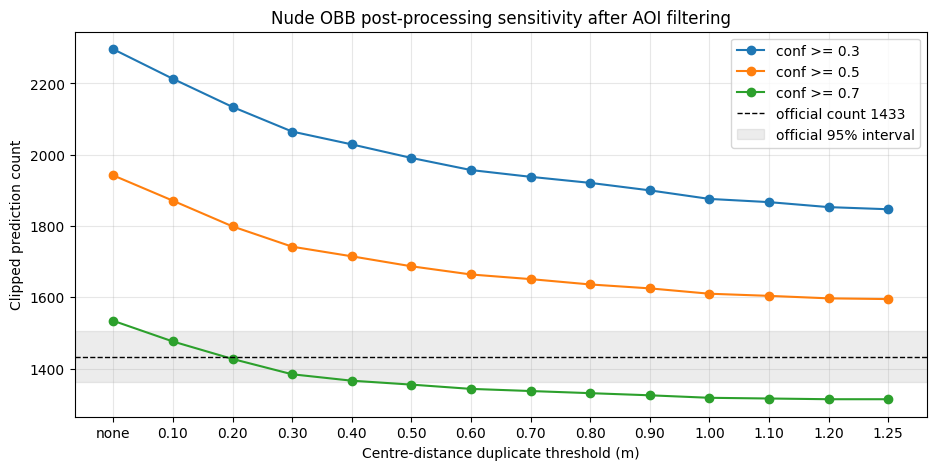

In [10]:
import matplotlib.pyplot as plt
plot_data = summary_clipped.copy()
plot_data['distance_sort'] = plot_data['distance_threshold_m'].fillna(-1)
plot_data = plot_data.sort_values(['confidence_threshold', 'distance_sort'])
plot_data['distance_label'] = plot_data['distance_threshold_m'].apply(
    lambda value: 'none' if pd.isna(value) else f'{value:.2f}'
)

fig, ax = plt.subplots(figsize=(11, 5))
for conf_threshold, group in plot_data.groupby('confidence_threshold'):
    ax.plot(
        group['distance_label'],
        group['clipped_final_count'],
        marker='o',
        label=f'conf >= {conf_threshold}',
    )

ax.axhline(1433, color='black', linestyle='--', linewidth=1, label='official count 1433')
ax.axhspan(1361, 1505, color='grey', alpha=0.15, label='official 95% interval')
ax.set_xlabel('Centre-distance duplicate threshold (m)')
ax.set_ylabel('Clipped prediction count')
ax.set_title('Nude OBB post-processing sensitivity after AOI filtering')
ax.legend()
ax.grid(True, alpha=0.3)

plot_path = EXPERIMENT_DIR / 'nude_obb_postprocessing_sensitivity_clipped.png'
fig.savefig(plot_path, dpi=300, bbox_inches='tight')
print('saved plot:', plot_path)

plt.show()

## 9. Recommended GIS Check

Open a few output GeoJSON files from `results/obb_nude_experiments/clipped_to_aoi/` in QGIS and compare them against the imagery. Treat the results as exploratory unless the removed detections are visibly outside the AOI or duplicate parking spaces.

saved plot: /content/gdrive/MyDrive/ParkingSpaceDetection/results/obb_nude_experiments/nude_obb_cddt_percent_removed.png


,confidence_threshold,distance_threshold_m,clipped_final_count,percent_removed
0,0.3,NaN,2296,0.000000
1,0.3,0.10,2213,3.614983
2,0.3,0.20,2134,7.055749
3,0.3,0.30,2065,10.060976
4,0.3,0.40,2029,11.628920
5,0.3,0.50,1991,13.283972
6,0.3,0.60,1957,14.764808
7,0.3,0.70,1938,15.592334
8,0.3,0.80,1921,16.332753
9,0.3,0.90,1900,17.247387


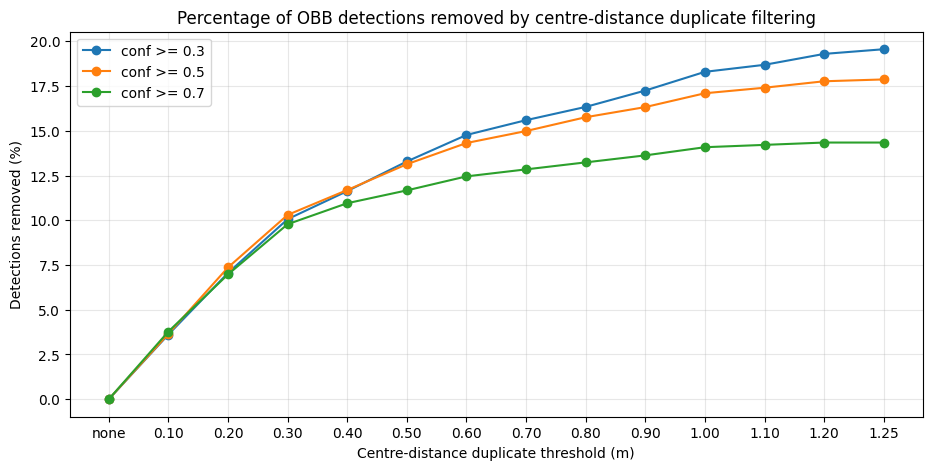

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

CSV_PATH = EXPERIMENT_DIR / "summary_clipped.csv"

summary_from_csv = pd.read_csv(CSV_PATH)

plot_data = summary_from_csv.copy()

# Sort distance thresholds: none first, then numeric thresholds
plot_data["distance_sort"] = plot_data["distance_threshold_m"].fillna(-1)
plot_data = plot_data.sort_values(["confidence_threshold", "distance_sort"])

# Baseline per confidence level: count with no distance duplicate removal
baseline = (
    plot_data[plot_data["distance_threshold_m"].isna()]
    .set_index("confidence_threshold")["clipped_final_count"]
    .to_dict()
)

plot_data["percent_removed"] = plot_data.apply(
    lambda row: (
        (baseline[row["confidence_threshold"]] - row["clipped_final_count"])
        / baseline[row["confidence_threshold"]]
        * 100
    ),
    axis=1,
)

plot_data["distance_label"] = plot_data["distance_threshold_m"].apply(
    lambda value: "none" if pd.isna(value) else f"{value:.2f}"
)

fig, ax = plt.subplots(figsize=(11, 5))

for conf_threshold, group in plot_data.groupby("confidence_threshold"):
    ax.plot(
        group["distance_label"],
        group["percent_removed"],
        marker="o",
        label=f"conf >= {conf_threshold}",
    )

ax.set_xlabel("Centre-distance duplicate threshold (m)")
ax.set_ylabel("Detections removed (%)")
ax.set_title("Percentage of OBB detections removed by centre-distance duplicate filtering")
ax.legend()
ax.grid(True, alpha=0.3)

plot_path = EXPERIMENT_DIR / "nude_obb_cddt_percent_removed.png"
fig.savefig(plot_path, dpi=300, bbox_inches="tight")

print("saved plot:", plot_path)

display(plot_data[[
    "confidence_threshold",
    "distance_threshold_m",
    "clipped_final_count",
    "percent_removed",
]])

plt.show()

In [16]:
SAVE_DIR = EXPERIMENT_DIR
SAVE_DIR.mkdir(parents=True, exist_ok=True)

plot_path = SAVE_DIR / "nude_obb_cddt_percent_removed.png"

fig.savefig(plot_path, dpi=300, bbox_inches="tight")

print("saved plot to Google Drive:")
print(plot_path)

saved plot to Google Drive:
/content/gdrive/MyDrive/ParkingSpaceDetection/results/obb_nude_experiments/nude_obb_cddt_percent_removed.png
